In [1]:
import csv
import numpy as np
from random import gauss, uniform
import pickle as pkl
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import orlab as orl

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 22
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
def unpickler(path):
    with open(path, 'rb') as file:
        return pkl.load(file)

In [3]:
wind_speeds = [0, 5, 9, 10, 13, 15, 20]

data = []
events = []

for wind_speed in wind_speeds:
    wind_speed_str = str(f'{wind_speed:.0f}')

    data.append(unpickler(f'./Data Files/{wind_speed_str}_monte_carlo_data.pkl'))
    events.append(unpickler(f'./Data Files/{wind_speed_str}_monte_carlo_events.pkl'))

In [4]:
print(np.shape(data[0]))

(1000,)


In [5]:
all_apogee_times = []
all_apogee_altitudes = []
all_max_velocity = []
all_max_acceleration = []
all_off_rod_velocity = []
all_main_deployment_times = []
all_full_flight_duration = []
all_ground_hit_velocity = []
all_off_rod_stability = []
all_drift_distances = []

for i, wind_speed in enumerate(wind_speeds):
    apogee_times = []
    apogee_altitudes = []
    max_velocity = []
    max_acceleration = []
    off_rod_velocity = []
    main_deployment_times = []
    full_flight_duration = []
    ground_hit_velocity = []
    off_rod_stability = []
    drift_distances = []

    for sim, event in zip(data[i], events[i]):
        apogee_times.append(event[orl.FlightEvent.APOGEE][0])
        apogee_altitudes.append(sim[orl.FlightDataType.TYPE_ALTITUDE][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.APOGEE])[0][0]] * 3.28084) # Convert to feet
        max_velocity.append(max(sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL]) * 3.28084) # Convert to feet/s
        max_acceleration.append(max(sim[orl.FlightDataType.TYPE_ACCELERATION_TOTAL][np.where(sim[orl.FlightDataType.TYPE_TIME] < event[orl.FlightEvent.APOGEE])]) * 3.28084) # Convert to feet/s^2
        off_rod_velocity.append(sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.LAUNCHROD])[0][0]] * 3.28084) # Convert to feet/s
        main_deployment_times.append(event[orl.FlightEvent.RECOVERY_DEVICE_DEPLOYMENT][1])
        full_flight_duration.append(event[orl.FlightEvent.GROUND_HIT][0])
        ground_hit_velocity.append(sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.GROUND_HIT])[0][0]] * 3.28084) # Convert to feet/s
        off_rod_stability.append(sim[orl.FlightDataType.TYPE_STABILITY][np.where(np.isnan(sim[orl.FlightDataType.TYPE_STABILITY]) == False)[0][0]])

        apogee_pos_x = sim[orl.FlightDataType.TYPE_POSITION_X][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.APOGEE])[0][0]] * 3.28084  # Convert to feet
        apogee_pos_y = sim[orl.FlightDataType.TYPE_POSITION_Y][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.APOGEE])[0][0]] * 3.28084  # Convert to feet

        landing_pos_x = sim[orl.FlightDataType.TYPE_POSITION_X][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.GROUND_HIT])[0][0]] * 3.28084  # Convert to feet
        landing_pos_y = sim[orl.FlightDataType.TYPE_POSITION_Y][np.where(sim[orl.FlightDataType.TYPE_TIME] == event[orl.FlightEvent.GROUND_HIT])[0][0]] * 3.28084  # Convert to feet

        drift_distances.append(np.sqrt((landing_pos_x - apogee_pos_x)**2 + (landing_pos_y - apogee_pos_y)**2))

    all_apogee_times.append(apogee_times)
    all_apogee_altitudes.append(apogee_altitudes)
    all_max_velocity.append(max_velocity)
    all_max_acceleration.append(max_acceleration)
    all_off_rod_velocity.append(off_rod_velocity)
    all_main_deployment_times.append(main_deployment_times)
    all_full_flight_duration.append(full_flight_duration)
    all_ground_hit_velocity.append(ground_hit_velocity)
    all_off_rod_stability.append(off_rod_stability)
    all_drift_distances.append(drift_distances)

In [6]:
print(all_off_rod_stability)

[[np.float64(2.829917430813235), np.float64(2.6832426641328806), np.float64(2.77727467043391), np.float64(2.7270986504805537), np.float64(2.699216393414498), np.float64(2.72853434672639), np.float64(2.6204323937701286), np.float64(2.691221760413408), np.float64(2.6730206019101077), np.float64(2.872334092871259), np.float64(2.7204970166915166), np.float64(2.743749807995931), np.float64(2.7264491269132365), np.float64(2.733943375046012), np.float64(2.631989253248629), np.float64(2.7747436715093423), np.float64(2.5221816928459058), np.float64(2.7862018123758996), np.float64(2.7513954823214206), np.float64(2.6314415970122784), np.float64(2.6909394502473036), np.float64(2.8824113250971233), np.float64(2.712879795272957), np.float64(2.8115607011068966), np.float64(2.6309317494406304), np.float64(2.852970297104068), np.float64(2.881432667574287), np.float64(2.6903828765134747), np.float64(2.571202224874482), np.float64(2.64676989951054), np.float64(2.5794405093303534), np.float64(2.6649929639

In [7]:
all_descent_times = np.array(all_full_flight_duration) - np.array(all_apogee_times)

In [8]:
avg_apogee_times = np.zeros((len(wind_speeds), 1))
std_apogee_times = np.zeros((len(wind_speeds), 1))

avg_apogee_altitudes = np.zeros((len(wind_speeds), 1))
std_apogee_altitudes = np.zeros((len(wind_speeds), 1))

avg_max_velocity = np.zeros((len(wind_speeds), 1))
std_max_velocity = np.zeros((len(wind_speeds), 1))

avg_max_acceleration = np.zeros((len(wind_speeds), 1))
std_max_acceleration = np.zeros((len(wind_speeds), 1))

avg_off_rod_velocity = np.zeros((len(wind_speeds), 1))
std_off_rod_velocity = np.zeros((len(wind_speeds), 1))

avg_full_flight_duration = np.zeros((len(wind_speeds), 1))
std_full_flight_duration = np.zeros((len(wind_speeds), 1))

avg_ground_hit_velocity = np.zeros((len(wind_speeds), 1))
std_ground_hit_velocity = np.zeros((len(wind_speeds), 1))

avg_off_rod_stability = np.zeros((len(wind_speeds), 1))
std_off_rod_stability = np.zeros((len(wind_speeds), 1))

avg_drift_distances = np.zeros((len(wind_speeds), 1))
std_drift_distances = np.zeros((len(wind_speeds), 1))

avg_descent_times = np.zeros((len(wind_speeds), 1))
std_descent_times = np.zeros((len(wind_speeds), 1))

for i, wind_speed in enumerate(wind_speeds):
    for j, fin_shape in enumerate(['Tapered Swept']):
        avg_apogee_altitudes[i, j] = np.mean(all_apogee_altitudes[i])
        std_apogee_altitudes[i, j] = np.std(all_apogee_altitudes[i])

        avg_ground_hit_velocity[i, j] = np.mean(all_ground_hit_velocity[i])
        std_ground_hit_velocity[i, j] = np.std(all_ground_hit_velocity[i])

        avg_max_acceleration[i, j] = np.mean(all_max_acceleration[i])
        std_max_acceleration[i, j] = np.std(all_max_acceleration[i])

        avg_off_rod_velocity[i, j] = np.mean(all_off_rod_velocity[i])
        std_off_rod_velocity[i, j] = np.std(all_off_rod_velocity[i])

        avg_full_flight_duration[i, j] = np.mean(all_full_flight_duration[i])
        std_full_flight_duration[i, j] = np.std(all_full_flight_duration[i])

        avg_ground_hit_velocity[i, j] = np.mean(all_ground_hit_velocity[i])
        std_ground_hit_velocity[i, j] = np.std(all_ground_hit_velocity[i])

        avg_off_rod_stability[i, j] = np.mean(all_off_rod_stability[i])
        std_off_rod_stability[i, j] = np.std(all_off_rod_stability[i])

        avg_drift_distances[i, j] = np.mean(all_drift_distances[i])
        std_drift_distances[i, j] = np.std(all_drift_distances[i])

        avg_descent_times[i, j] = np.mean(all_descent_times[i])
        std_descent_times[i, j] = np.std(all_descent_times[i])

In [9]:
df = pd.read_csv('./Data Files/9_monte_carlo_parameters.csv')
total_masses = []

for i in range(len(df)):
    total_mass = 0
    for column in df.columns:
        if 'Mass' in column:
            total_mass += df[column][i]
    total_masses.append(total_mass)

print(f'Average Total Mass: {np.mean(total_masses) / 0.453592:.3f} lbs')

Average Total Mass: 36.875 lbs


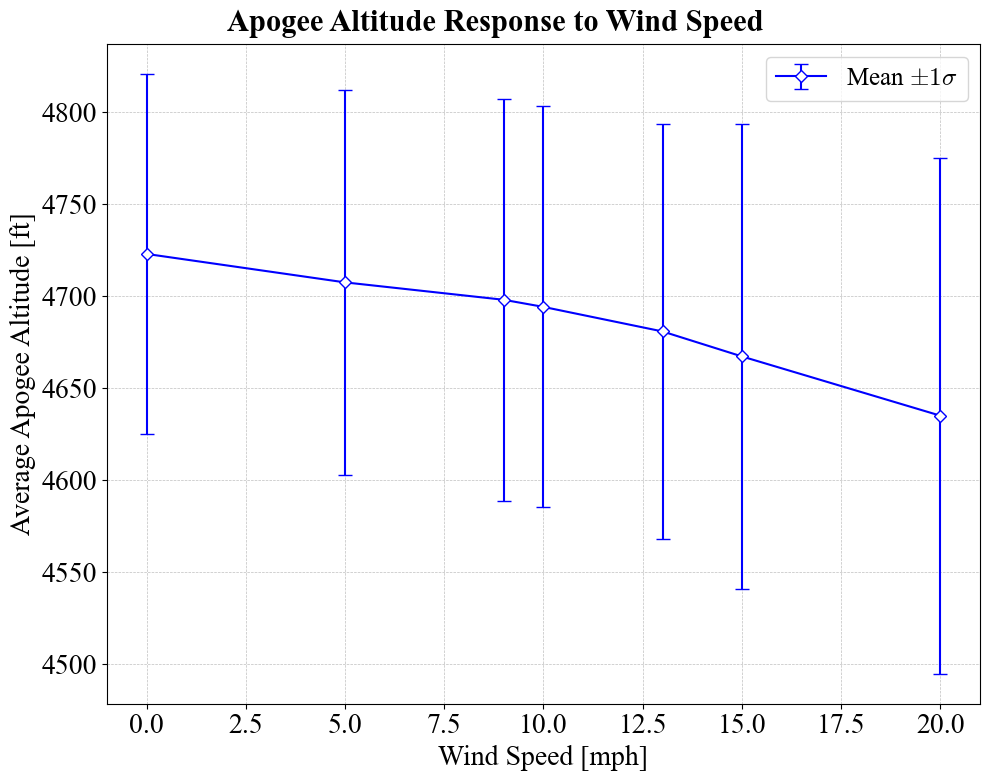

In [10]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Apogee Altitude Response to Wind Speed', y=0.97)

for i, fin_shape in enumerate(['Tapered Swept']):
    ax.errorbar(wind_speeds, avg_apogee_altitudes[:, i], yerr=std_apogee_altitudes[:, i], label=f'Mean $\pm 1 \sigma$', marker='D', capsize=5, markersize=6, linestyle='-', markerfacecolor='white', color='blue')

ax.set_xlabel('Wind Speed [mph]')
ax.set_ylabel('Average Apogee Altitude [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend()

fig.savefig('./Figures/Apogee Altitude Response to Wind Speed.png', dpi=300)

plt.show()

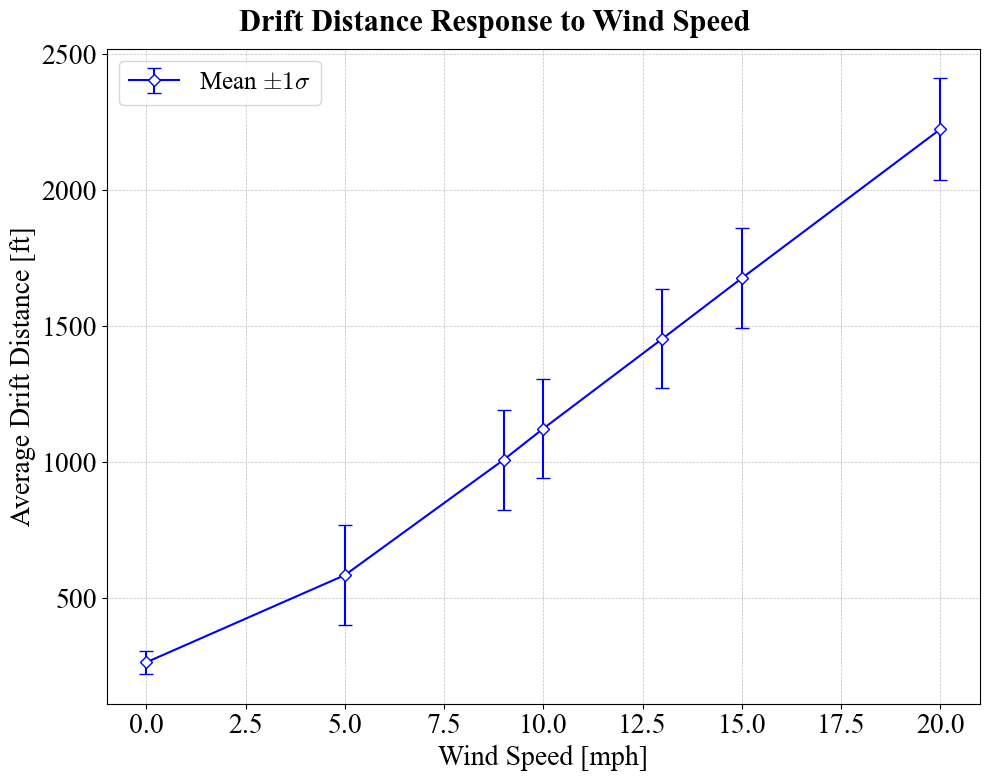

In [11]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Drift Distance Response to Wind Speed', y=0.97)

for i, fin_shape in enumerate(['Tapered Swept']):
    ax.errorbar(wind_speeds, avg_drift_distances[:, i], yerr=std_drift_distances[:, i], label=f'Mean $\pm 1 \sigma$', marker='D', capsize=5, markersize=6, linestyle='-', markerfacecolor='white', color='blue')

ax.set_xlabel('Wind Speed [mph]')
ax.set_ylabel('Average Drift Distance [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend()

fig.savefig('./Figures/Drift Distance Response to Wind Speed.png', dpi=300)

plt.show()

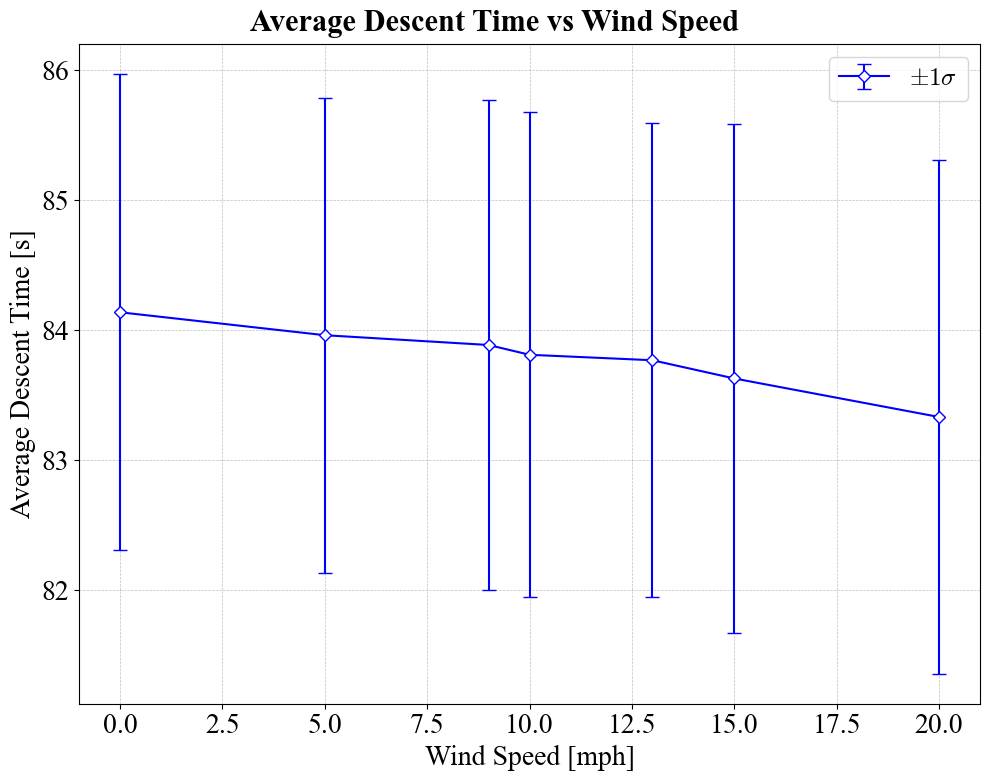

In [12]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Average Descent Time vs Wind Speed', y=0.97)

for i, fin_shape in enumerate(['Tapered Swept']):
    ax.errorbar(wind_speeds, avg_descent_times[:, i], yerr=std_descent_times[:, i], label=f'$\pm 1 \sigma$', marker='D', capsize=5, markersize=6, linestyle='-', markerfacecolor='white', color='blue')

ax.set_xlabel('Wind Speed [mph]')
ax.set_ylabel('Average Descent Time [s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend()

# fig.savefig('./Figures/Average Descent Time vs Wind Speed.png', dpi=300)
plt.show()

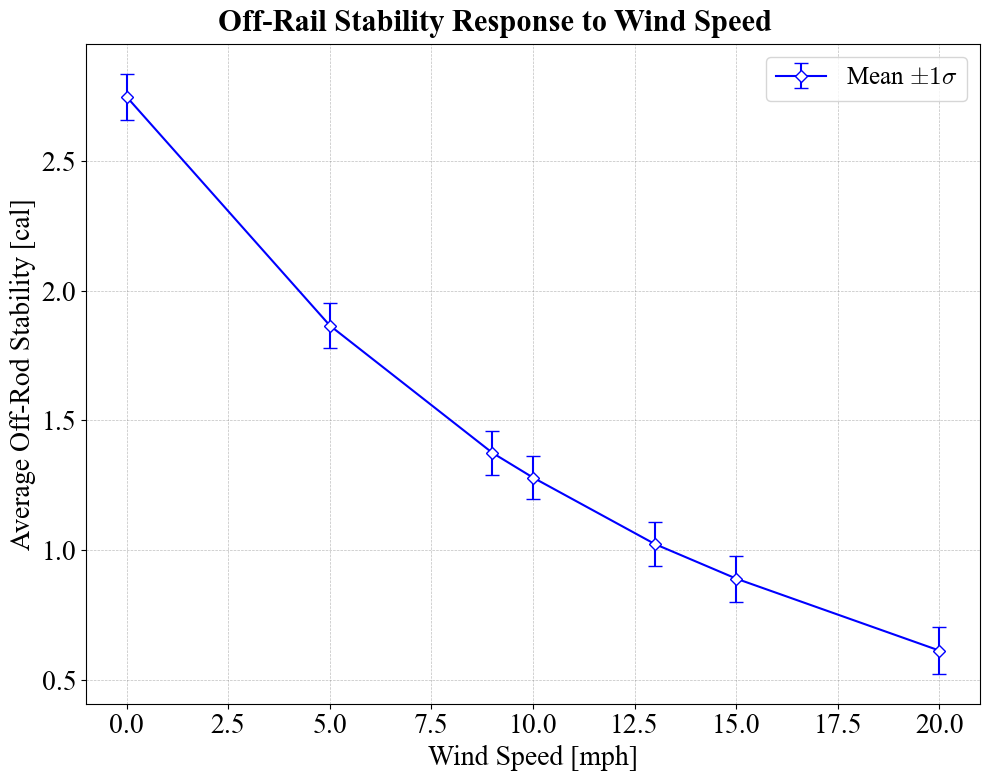

In [13]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Off-Rail Stability Response to Wind Speed', y=0.97)

for i, fin_shape in enumerate(['Tapered Swept']):
    ax.errorbar(wind_speeds, avg_off_rod_stability[:, i], yerr=std_off_rod_stability[:, i], label=f'Mean $\pm 1 \sigma$', marker='D', capsize=5, markersize=6, linestyle='-', markerfacecolor='white', color='blue')

ax.set_xlabel('Wind Speed [mph]')
ax.set_ylabel('Average Off-Rod Stability [cal]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend()

fig.savefig('./Figures/Off-Rod Stability Response to Wind Speed.png', dpi=300)

plt.show()

In [14]:
average_of_calculations = [144.39, 680.02, 1053.21, 1154.64, 1473.96, 1694.48, 2260.54]

for i, num in enumerate(avg_drift_distances[:, -1]):
    print(f'{num:.2f}')
    print(f'{np.abs(average_of_calculations[i] - num) / num * 100:.2f}')

263.79
45.26
584.19
16.40
1008.22
4.46
1123.06
2.81
1453.44
1.41
1675.84
1.11
2223.40
1.67


In [15]:
print('Apogee Altitude [ft]:')
print(f'{np.mean(all_apogee_altitudes):.0f} ± {np.std(all_apogee_altitudes):.0f}, {np.std(all_apogee_altitudes)/np.mean(all_apogee_altitudes)*100:.2f}%')
print('Drift Distance [ft]:')
print(f'{np.mean(all_drift_distances):.0f} ± {np.std(all_drift_distances):.0f}, {np.std(all_drift_distances)/np.mean(all_drift_distances)*100:.2f}%')
print('Descent Time [s]:')
print(f'{np.mean(all_descent_times):.2f} ± {np.std(all_descent_times):.2f}, {np.std(all_descent_times)/np.mean(all_descent_times)*100:.2f}%')
print('Off-Rod Velocity [ft/s]:')
print(f'{np.mean(all_off_rod_velocity):.2f} ± {np.std(all_off_rod_velocity):.3f}, {np.std(all_off_rod_velocity)/np.mean(all_off_rod_velocity)*100:.2f}%')
print('Maximum Velocity [ft/s]:')
print(f'{np.mean(all_max_velocity):.2f} ± {np.std(all_max_velocity):.3f}, {np.std(all_max_velocity)/np.mean(all_max_velocity)*100:.2f}%')
print('Landing Velocity [ft/s]:')
print(f'{np.mean(all_ground_hit_velocity):.2f} ± {np.std(all_ground_hit_velocity):.3f}, {np.std(all_ground_hit_velocity)/np.mean(all_ground_hit_velocity)*100:.2f}%')
print(f'Maximum Acceleration [ft/s²]:')
print(f'{np.mean(all_max_acceleration):.2f} ± {np.std(all_max_acceleration):.3f} ({np.mean(all_max_acceleration)/32.17:.2f} ± {np.std(all_max_acceleration)/32.17:.3f}), {np.std(all_max_acceleration)/np.mean(all_max_acceleration)*100:.2f}%')
print(f'Off-Rail Stability [cal]:')
print(f'{np.mean(all_off_rod_stability):.2f} ± {np.std(all_off_rod_stability):.3f}, {np.std(all_off_rod_stability)/np.mean(all_off_rod_stability)*100:.2f}%')

Apogee Altitude [ft]:
4687 ± 118, 2.52%
Drift Distance [ft]:
1190 ± 637, 53.51%
Descent Time [s]:
83.79 ± 1.89, 2.26%
Off-Rod Velocity [ft/s]:
87.37 ± 1.015, 1.16%
Maximum Velocity [ft/s]:
619.40 ± 10.072, 1.63%
Landing Velocity [ft/s]:
15.68 ± 0.282, 1.80%
Maximum Acceleration [ft/s²]:
329.55 ± 5.509 (10.24 ± 0.171), 1.67%
Off-Rail Stability [cal]:
1.40 ± 0.668, 47.76%


In [67]:
print('Average Apogee Time:')
print(f'{np.mean(all_apogee_times):.2f} ± {np.std(all_apogee_times):.2f}, {np.std(all_apogee_times)/np.mean(all_apogee_times)*100:.2f}%')
print('Average Main Deployment Time:')
print(f'{np.mean(all_main_deployment_times):.2f} ± {np.std(all_main_deployment_times):.2f}, {np.std(all_main_deployment_times)/np.mean(all_main_deployment_times)*100:.2f}%')
print('Average Total Flight Time:')
print(f'{np.mean(all_full_flight_duration):.2f} ± {np.std(all_full_flight_duration):.2f}, {np.std(all_full_flight_duration)/np.mean(all_full_flight_duration)*100:.2f}%')

print('Drogue Descent Time:')
print(f'{np.mean(np.array(all_main_deployment_times) - np.array(all_apogee_times)):.5f} ± {np.std(np.array(all_main_deployment_times) - np.array(all_apogee_times)):.5f}, {np.std(np.array(all_main_deployment_times) - np.array(all_apogee_times))/np.mean(np.array(all_main_deployment_times) - np.array(all_apogee_times))*100:.5f}%')
print('Main Descent Time:')
print(f'{np.mean(np.array(all_full_flight_duration) - np.array(all_main_deployment_times)):.5f} ± {np.std(np.array(all_full_flight_duration) - np.array(all_main_deployment_times)):.5f}, {np.std(np.array(all_full_flight_duration) - np.array(all_main_deployment_times))/np.mean(np.array(all_full_flight_duration) - np.array(all_main_deployment_times))*100:.5f}%')

Average Apogee Time:
17.09 ± 0.21, 1.20%
Average Main Deployment Time:
58.09 ± 1.46, 2.51%
Average Total Flight Time:
100.88 ± 2.02, 2.01%
Drogue Descent Time:
41.00454 ± 1.28223, 3.12703%
Main Descent Time:
42.78372 ± 1.10270, 2.57739%


In [17]:
exclude = ['Apogee', 'Drift Distance', 'Descent Time', 'Landing Velocity', 'Off-Rod Stability']
N = 6
fin_shapes = ['Tapered Swept']

all_dfs = []

for fin_shape in fin_shapes:
    dfs = []
    for wind_speed in wind_speeds:
        wind_speed_input = wind_speed
        df = pd.read_csv(f'./Data Files/{wind_speed_input}_monte_carlo_parameters.csv')
        dfs.append(df)

    concatenated_df = pd.concat(dfs, ignore_index=True)

    concatenated_df['Apogee'] = [item for sublist in all_apogee_altitudes for item in sublist]
    concatenated_df['Drift Distance'] = [item for sublist in all_drift_distances for item in sublist]
    concatenated_df['Descent Time'] = [item for sublist in all_descent_times for item in sublist]
    concatenated_df['Landing Velocity'] = [item for sublist in all_ground_hit_velocity for item in sublist]
    concatenated_df['Off-Rod Stability'] = [item for sublist in all_off_rod_stability for item in sublist]

    corr = concatenated_df.corr(method='pearson')['Apogee'].sort_values(ascending=False)
    corr = corr.drop(exclude)

    # Sort by absolute correlation magnitude
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    # Select top N
    top_N = top_corr.head(N)

    # Print nicely
    print('CORRELATION RESULTS FOR APOGEE ALTITUDE')
    print("========================================")
    for param, value in top_N.items():
        print(f"  {param:<15s}  r = {value: .3f}  |r| = {abs(value): .3f}")

    corr = concatenated_df.corr(method='pearson')['Drift Distance'].sort_values(ascending=False)
    corr = corr.drop(exclude)

    # Sort by absolute correlation magnitude
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    # Select top N
    top_N = top_corr.head(N)

    # Print nicely
    print('CORRELATION RESULTS FOR DRIFT DISTANCE')
    print("========================================")
    for param, value in top_N.items():
        print(f"  {param:<15s}  r = {value: .3f}  |r| = {abs(value): .3f}")

    corr = concatenated_df.corr(method='pearson')['Descent Time'].sort_values(ascending=False)
    corr = corr.drop(exclude)

    # Sort by absolute correlation magnitude
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    # Select top N
    top_N = top_corr.head(N)

    # Print nicely
    print('CORRELATION RESULTS FOR DESCENT TIME')
    print("========================================")
    for param, value in top_N.items():
        print(f"  {param:<15s}  r = {value: .3f}  |r| = {abs(value): .3f}")

    corr = concatenated_df.corr(method='pearson')['Landing Velocity'].sort_values(ascending=False)
    corr = corr.drop(exclude)

    # Sort by absolute correlation magnitude
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    # Select top N
    top_N = top_corr.head(N)

    # Print nicely
    print('CORRELATION RESULTS FOR LANDING VELOCITY')
    print("========================================")
    for param, value in top_N.items():
        print(f"  {param:<15s}  r = {value: .3f}  |r| = {abs(value): .3f}")

    corr = concatenated_df.corr(method='pearson')['Off-Rod Stability'].sort_values(ascending=False)
    corr = corr.drop(exclude)

    # Sort by absolute correlation magnitude
    top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    # Select top N
    top_N = top_corr.head(N)

    # Print nicely
    print('CORRELATION RESULTS FOR OFF-ROD STABILITY')
    print("========================================")
    for param, value in top_N.items():
        print(f"  {param:<15s}  r = {value: .3f}  |r| = {abs(value): .3f}")

    all_dfs.append(concatenated_df)


CORRELATION RESULTS FOR APOGEE ALTITUDE
  Payload|Mass [kg]  r = -0.513  |r| =  0.513
  Launch Rod Angle [deg]  r = -0.310  |r| =  0.310
  AV Bay|Mass [kg]  r = -0.298  |r| =  0.298
  Air Temperature [K]  r =  0.223  |r| =  0.223
  Wind Speed [mph]  r = -0.220  |r| =  0.220
  Main Parachute|Mass [kg]  r = -0.184  |r| =  0.184
CORRELATION RESULTS FOR DRIFT DISTANCE
  Wind Speed [mph]  r =  0.959  |r| =  0.959
  NASA Middle Body Tube|Outer Diameter [m]  r = -0.026  |r| =  0.026
  Air Temperature [K]  r = -0.024  |r| =  0.024
  D-Link (Motor Tube)|Mass [kg]  r = -0.023  |r| =  0.023
  AV Bay|Mass [kg]  r = -0.020  |r| =  0.020
  Payload|Mass [kg]  r = -0.019  |r| =  0.019
CORRELATION RESULTS FOR DESCENT TIME
  Payload|Mass [kg]  r = -0.564  |r| =  0.564
  AV Bay|Mass [kg]  r = -0.351  |r| =  0.351
  Air Temperature [K]  r = -0.262  |r| =  0.262
  Main Parachute|Mass [kg]  r = -0.200  |r| =  0.200
  NASA Aft Body Tube|Mass [kg]  r = -0.190  |r| =  0.190
  Parachute Bag|Mass [kg]  r = -0.17

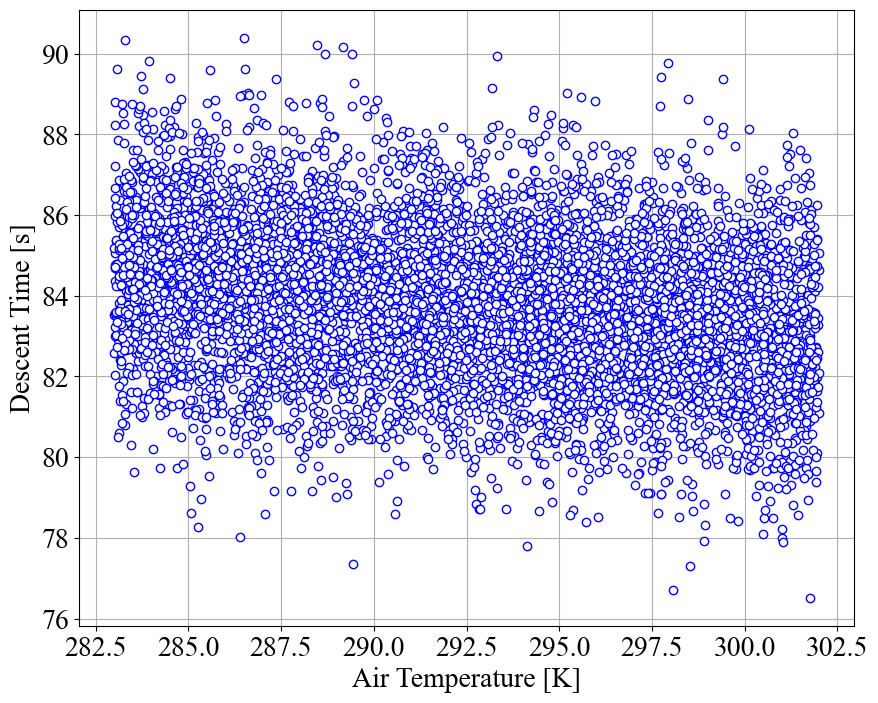

In [18]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(all_dfs[-1]['Air Temperature [K]'], all_dfs[-1]['Descent Time'], 'o', markerfacecolor='white', markeredgecolor='blue', markersize=6)
ax.set_xlabel('Air Temperature [K]')
ax.set_ylabel('Descent Time [s]')
ax.grid(True)

plt.show()

In [19]:
def openrocket_to_plot(file_path, code_to_run=None, **kwargs):
    # Reading in data
    df = pd.read_csv(file_path, comment='#')
    
    # Reading in events
    with open(file_path, 'r') as f:
        lines = f.readlines()
        event_lines = [line for line in lines if line.startswith('#')]

    # Extracting event names
    events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]

    # Extracting event times
    event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

    # Defining events to plot
    plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

    # Plotting flight profile
    fig = plt.figure()
    fig.set_tight_layout(kwargs.get('tight_layout', True))
    
    ax = fig.add_subplot()

    if code_to_run is not None:
        exec(code_to_run)

    elif kwargs.get('plot_type', 'altitude') == 'altitude':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax.set_ylabel('Altitude [ft]')

    elif kwargs.get('plot_type') == 'velocity':
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax.set_ylabel('Velocity [ft/s]')

    elif kwargs.get('plot_type') == 'acceleration':
        ax.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax.set_ylabel('Acceleration [ft/s²]')

    elif kwargs.get('plot_type') == 'all':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color='b', label='Altitude', linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '--'), color='r', label='Velocity', linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax.set_ylabel('Altitude [ft], Velocity [ft/s]')

        ax2 = ax.twinx()
        ax2.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-.'), color='g', label='Acceleration', linewidth=kwargs.get('linewidth', 2), zorder=kwargs.get('zorder', 1))
        ax2.set_ylabel('Acceleration [ft/s²]')

    drogue_deployed = False
    for event, event_time in zip(events, event_times):
        if event in plot_events:
            ax.axvline(event_time, linestyle='--', color='k')

            if event == 'RECOVERY_DEVICE_DEPLOYMENT':
                if not drogue_deployed:
                    # Label on right side near middle
                    event_label = 'Drogue Deployment'
                    drogue_deployed = True
                    ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
                else:
                    # Label on left side near top
                    event_label = 'Main Deployment'
                    ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

            elif event == 'BURNOUT':
                # Label on right side near top
                ax.text(event_time + 0.5, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)

            elif event == 'APOGEE' or event == 'GROUND_HIT':
                # Label on left side near middle
                ax.text(event_time - 0.3, np.mean(ax.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
            else:
                # Label on left side near top
                ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

    # fig.suptitle('Simulated Flight Profile', y=0.95)
    ax.set_xlabel('Time [s]')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    if kwargs.get('label', None) is not None: ax.legend(loc='upper right')

    if kwargs.get('plot_type') == 'all':
        return fig, ax, ax2
    return fig, ax
    

In [20]:
nominal_flight = pd.read_csv('./Nominal Flight.csv', comment='#')

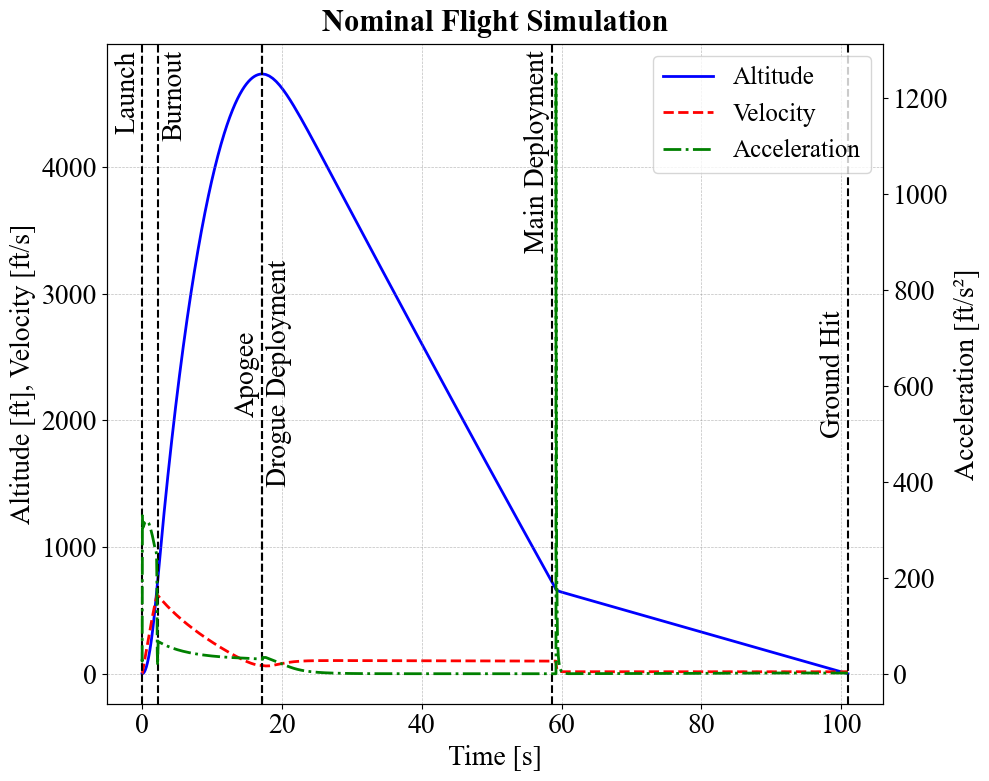

In [45]:
fig, ax1, ax2 = openrocket_to_plot('Nominal Flight.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('Nominal Flight Simulation', y=0.97)

fig.savefig('./Figures/Nominal Flight Simulation.png', dpi=300)

plt.show()

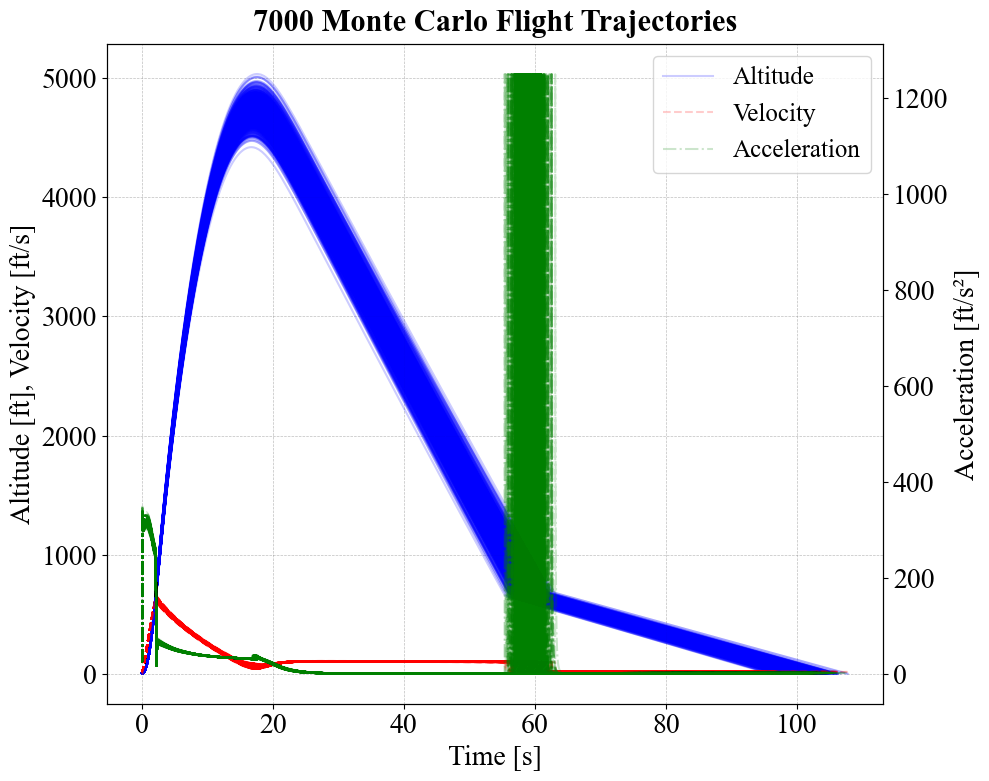

In [57]:
samples = len(data[0])

fig = plt.figure()
fig.set_tight_layout(True)
ax1 = fig.add_subplot()

fig.suptitle(f'7000 Monte Carlo Flight Trajectories', y=0.97)

ax2 = ax1.twinx()
for i, (sim, event) in enumerate(zip(data[0], events[0])):
    if i == 0:
        ax1.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_ALTITUDE] * 3.28084, color='blue', label='Altitude', alpha=0.2) # Convert to feet
        ax1.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL] * 3.28084, color='red', linestyle='--', label='Velocity', alpha=0.2) # Convert to feet/s
        ax2.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_ACCELERATION_TOTAL] * 3.28084, color='green', linestyle='-.', label='Acceleration', alpha=0.2) # Convert to feet/s^2
    else:
        ax1.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_ALTITUDE] * 3.28084, color='blue', alpha=0.2) # Convert to feet
        ax1.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL] * 3.28084, color='red', linestyle='--', alpha=0.2) # Convert to feet/s
        ax2.plot(sim[orl.FlightDataType.TYPE_TIME], sim[orl.FlightDataType.TYPE_ACCELERATION_TOTAL] * 3.28084, color='green', linestyle='-.', alpha=0.2) # Convert to feet/s^2

ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

fig.savefig('./Figures/Monte Carlo Flight Trajectories.png', dpi=300)

plt.show()

In [23]:
tapswept_array = np.array(data).reshape(-1)
times = np.array([sim[orl.FlightDataType.TYPE_TIME] for sim in tapswept_array], dtype=object)
altitudes = np.array([sim[orl.FlightDataType.TYPE_ALTITUDE] for sim in tapswept_array], dtype=object)
velocities = np.array([sim[orl.FlightDataType.TYPE_VELOCITY_TOTAL] for sim in tapswept_array], dtype=object)
accelerations = np.array([sim[orl.FlightDataType.TYPE_ACCELERATION_TOTAL] for sim in tapswept_array], dtype=object)

In [24]:
min_times = [time_array[0] for time_array in times]
overall_min_time = min(min_times)

print(overall_min_time)

max_times = [time_array[-1] for time_array in times]
overall_max_time = max(max_times)

print(overall_max_time)

0.01
107.79192920279768


In [25]:
mean_times = np.linspace(overall_min_time, overall_max_time, num=1000)

In [26]:
from scipy.interpolate import interp1d

aligned_alts = []
aligned_vs = []
aligned_accs = []

for t_i, h_i, v_i, a_i in zip(times, altitudes, velocities, accelerations):
    f1 = interp1d(t_i, h_i, kind='linear', bounds_error=False, fill_value=np.nan)
    f2 = interp1d(t_i, v_i, kind='linear', bounds_error=False, fill_value=np.nan)
    f3 = interp1d(t_i, a_i, kind='linear', bounds_error=False, fill_value=np.nan)

    aligned_alts.append(f1(mean_times))
    aligned_vs.append(f2(mean_times))
    aligned_accs.append(f3(mean_times))

aligned_alts = np.vstack(aligned_alts) * 3.28084 # shape (5000, len(mean_times))
avg_alts = np.nanmean(aligned_alts, axis=0)

aligned_vs = np.vstack(aligned_vs) * 3.28084 # shape (5000, len(mean_times))
avg_vs = np.nanmean(aligned_vs, axis=0)

aligned_accs = np.vstack(aligned_accs) * 3.28084 # shape (5000, len(mean_times))
avg_accs = np.nanmean(aligned_accs, axis=0)


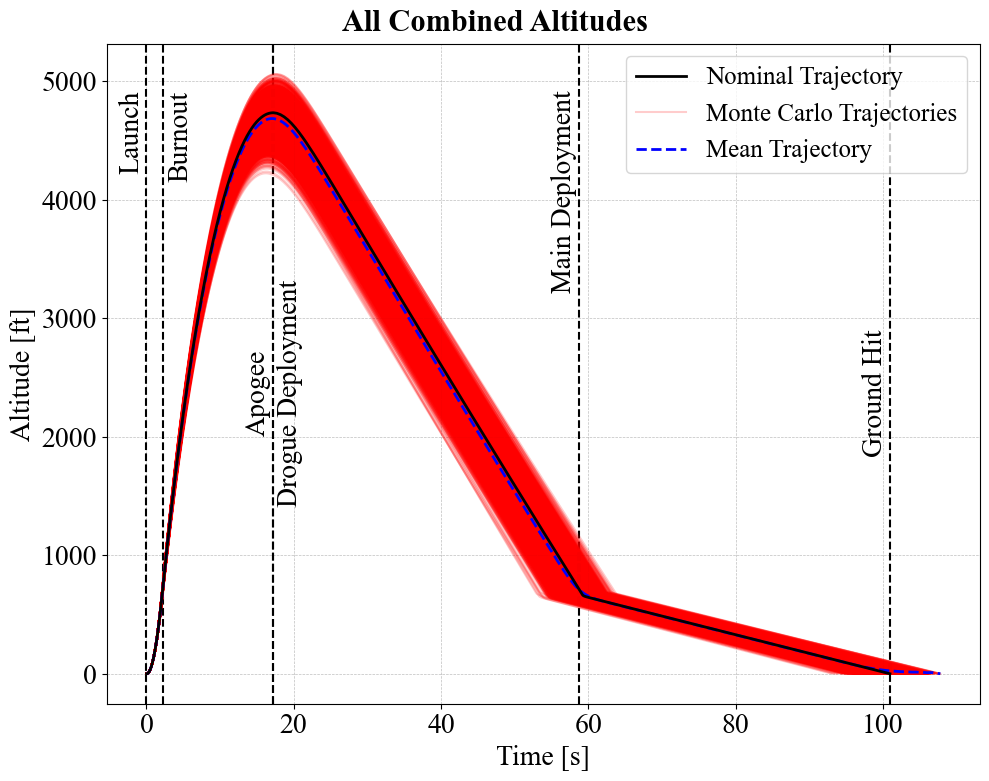

In [62]:
fig, ax = openrocket_to_plot('Nominal Flight.csv', plot_type='altitude', label='Nominal Trajectory', color='black', linewidth=2, zorder=10)

for i, alts in enumerate(aligned_alts):
    ax.plot(mean_times, alts, color='red', alpha=0.2, label='Monte Carlo Trajectories' if i == 0 else "") # Convert to feet

ax.plot(mean_times, avg_alts, color='blue', linestyle='--', linewidth=2, label='Mean Trajectory')  # Convert to feet

h1, l1 = ax.get_legend_handles_labels()

ax.legend(h1, l1, loc='upper right')
fig.suptitle('All Combined Altitudes', y=0.97)

fig.savefig('./Figures/All Combined Altitudes.png', dpi=300)

plt.show()

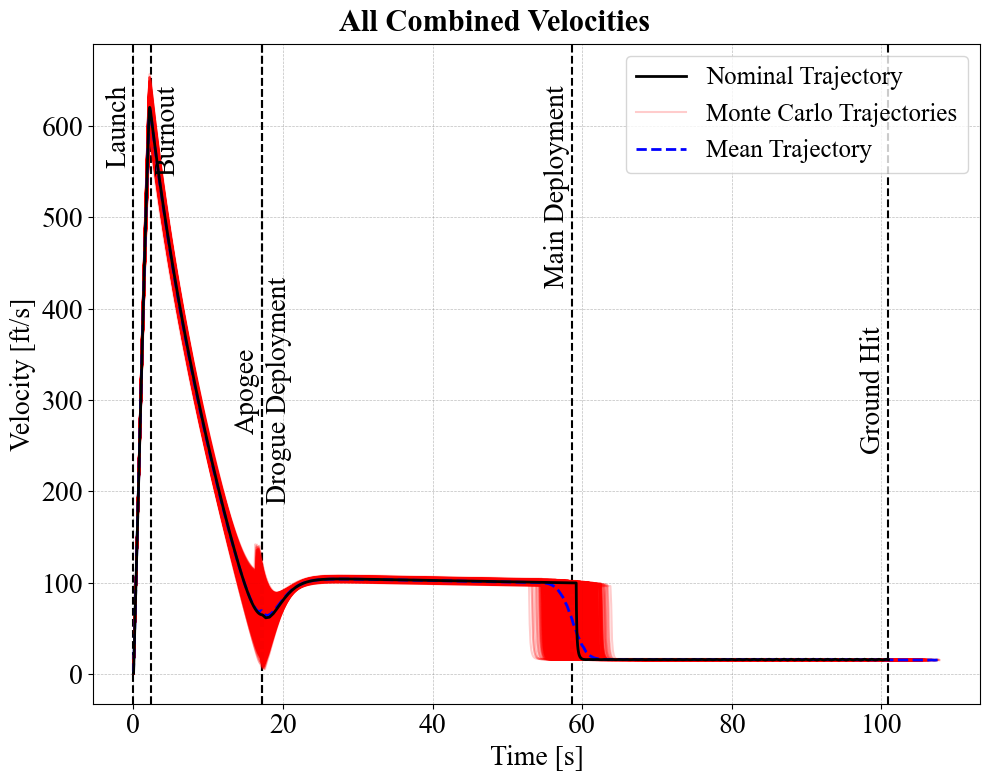

In [63]:
fig, ax = openrocket_to_plot('Nominal Flight.csv', plot_type='velocity', label='Nominal Trajectory', color='black', linewidth=2, zorder=10)

for i, vs in enumerate(aligned_vs):
    ax.plot(mean_times, vs, color='red', alpha=0.2, label='Monte Carlo Trajectories' if i == 0 else "") # Convert to feet

ax.plot(mean_times, avg_vs, color='blue', linestyle='--', linewidth=2, label='Mean Trajectory')  # Convert to feet

h1, l1 = ax.get_legend_handles_labels()

ax.legend(h1, l1, loc='upper right')
fig.suptitle('All Combined Velocities', y=0.97)

fig.savefig('./Figures/All Combined Velocities.png', dpi=300)

plt.show()

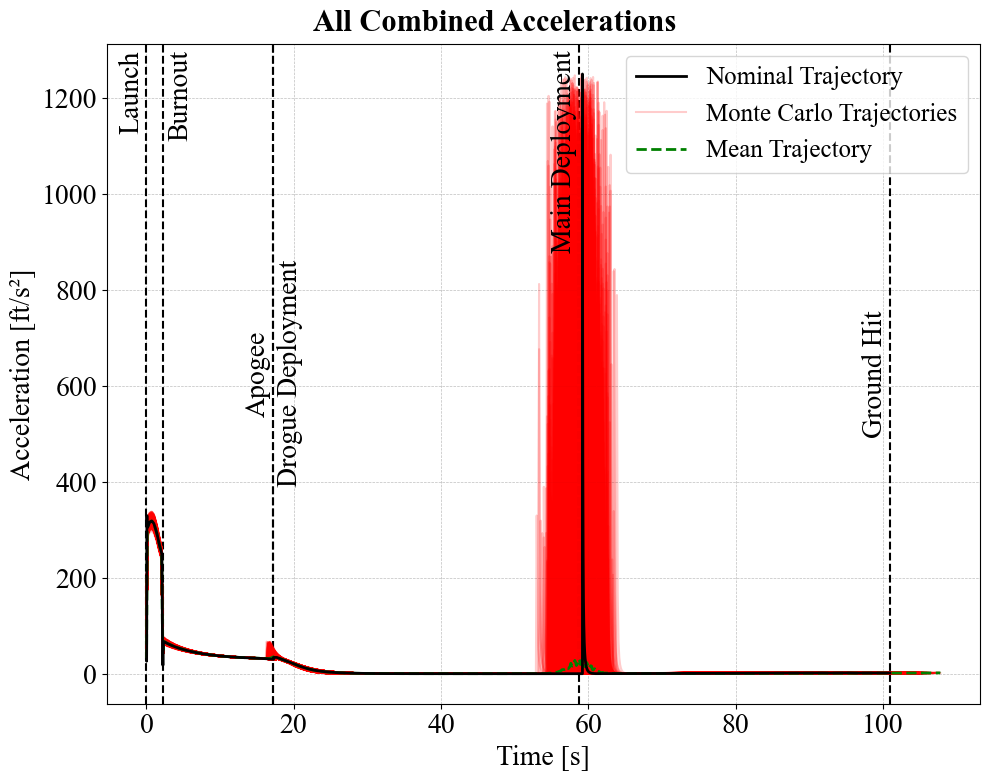

In [64]:
fig, ax = openrocket_to_plot('Nominal Flight.csv', plot_type='acceleration', label='Nominal Trajectory', color='black', linewidth=2, zorder=10)

for i, accs in enumerate(aligned_accs):
    ax.plot(mean_times, accs, color='red', alpha=0.2, label='Monte Carlo Trajectories' if i == 0 else "") # Convert to feet

ax.plot(mean_times, avg_accs, color='green', linestyle='--', linewidth=2, label='Mean Trajectory')  # Convert to feet

h1, l1 = ax.get_legend_handles_labels()

ax.legend(h1, l1, loc='upper right')
fig.suptitle('All Combined Accelerations', y=0.97)

fig.savefig('./Figures/All Combined Accelerations.png', dpi=300)

plt.show()

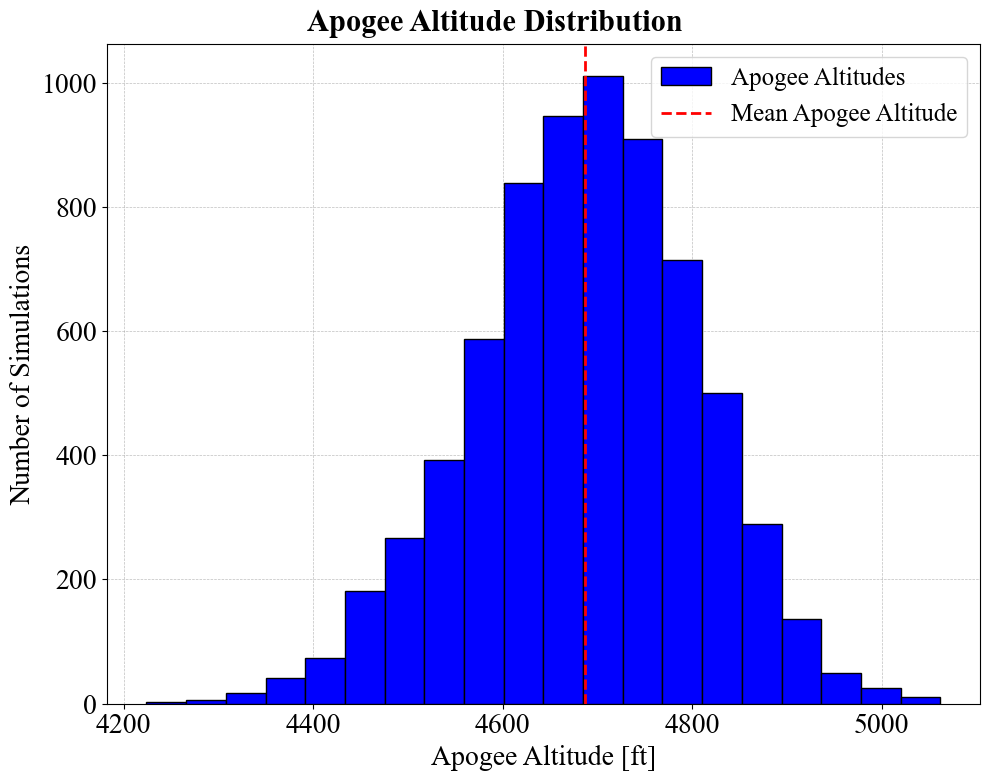

In [52]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Apogee Altitude Distribution', y=0.97)

apogee_arr = np.array(all_apogee_altitudes).reshape(-1)

ax.hist(apogee_arr, bins=20, edgecolor='black', facecolor='blue', zorder=10, label='Apogee Altitudes')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.axvline(np.mean(apogee_arr), color='red', linestyle='--', linewidth=2, label='Mean Apogee Altitude', zorder=15)

ax.set_xlabel('Apogee Altitude [ft]')
ax.set_ylabel('Number of Simulations')

ax.legend()

fig.savefig('./Figures/Apogee Altitude Distribution.png', dpi=300)

plt.show()

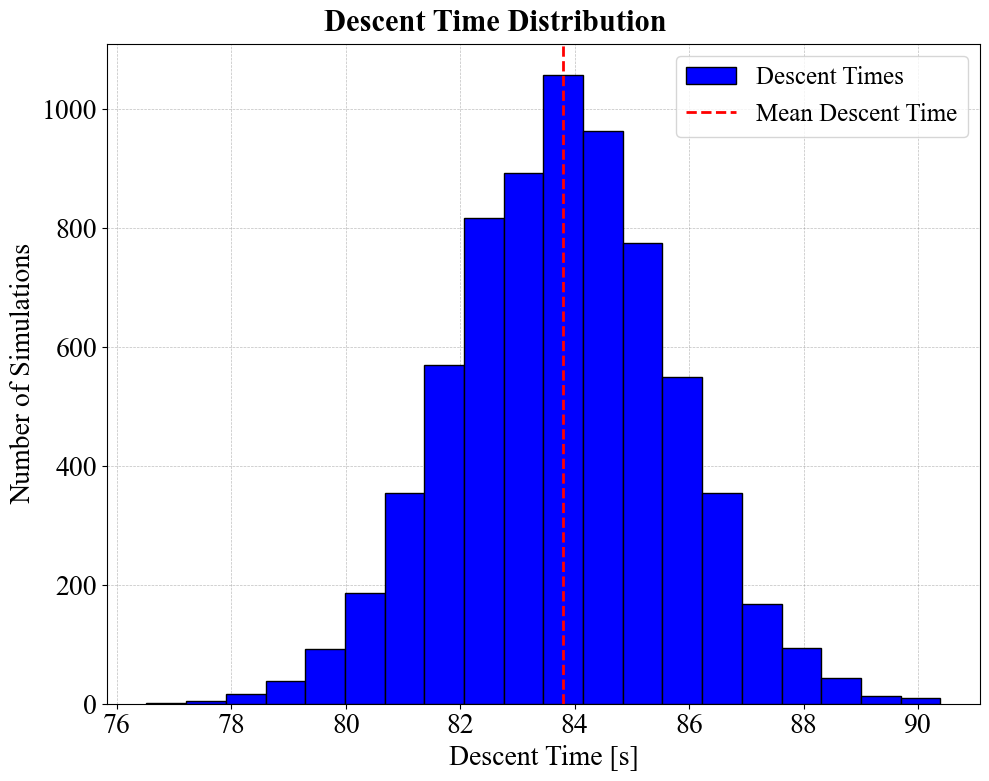

In [53]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Descent Time Distribution', y=0.97)

descent_time_arr = np.array(all_descent_times).reshape(-1)

ax.hist(descent_time_arr, bins=20, edgecolor='black', facecolor='blue', zorder=10, label='Descent Times')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.axvline(np.mean(descent_time_arr), color='red', linestyle='--', linewidth=2, label='Mean Descent Time', zorder=15)

ax.set_xlabel('Descent Time [s]')
ax.set_ylabel('Number of Simulations')

ax.legend()

fig.savefig('./Figures/Descent Time Distribution.png', dpi=300)

plt.show()

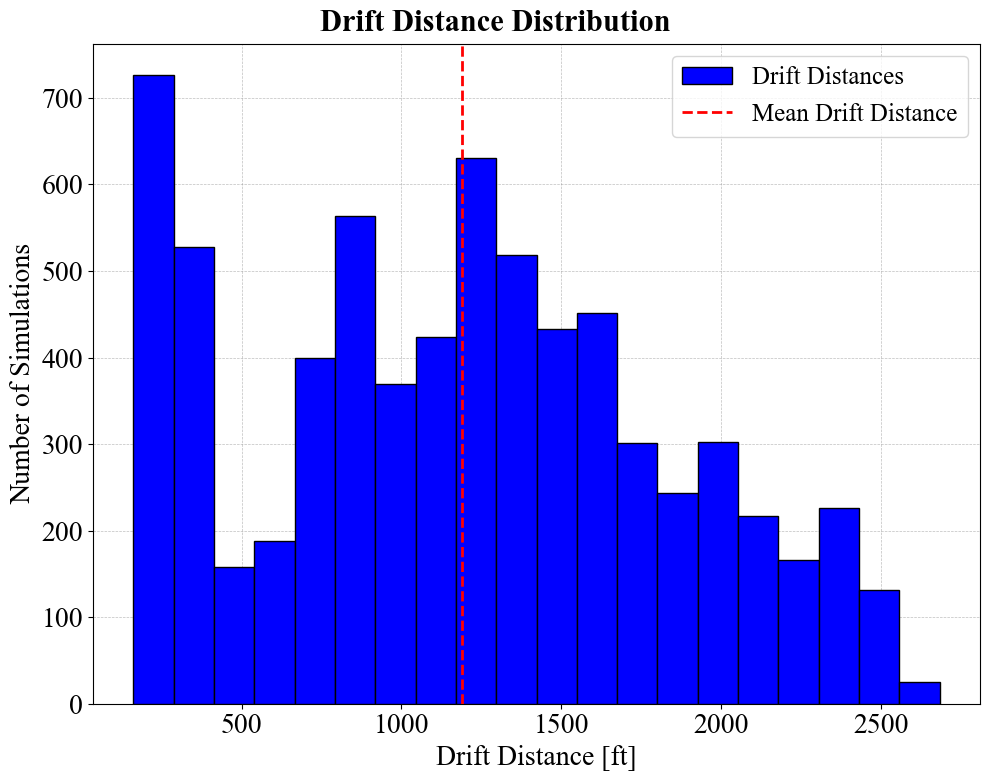

In [54]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Drift Distance Distribution', y=0.97)

drift_distance_arr = np.array(all_drift_distances).reshape(-1)

ax.hist(drift_distance_arr, bins=20, edgecolor='black', facecolor='blue', zorder=10, label='Drift Distances')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.axvline(np.mean(drift_distance_arr), color='red', linestyle='--', linewidth=2, label='Mean Drift Distance', zorder=15)

ax.set_xlabel('Drift Distance [ft]')
ax.set_ylabel('Number of Simulations')

ax.legend()

fig.savefig('./Figures/Drift Distance Distribution.png', dpi=300)

plt.show()

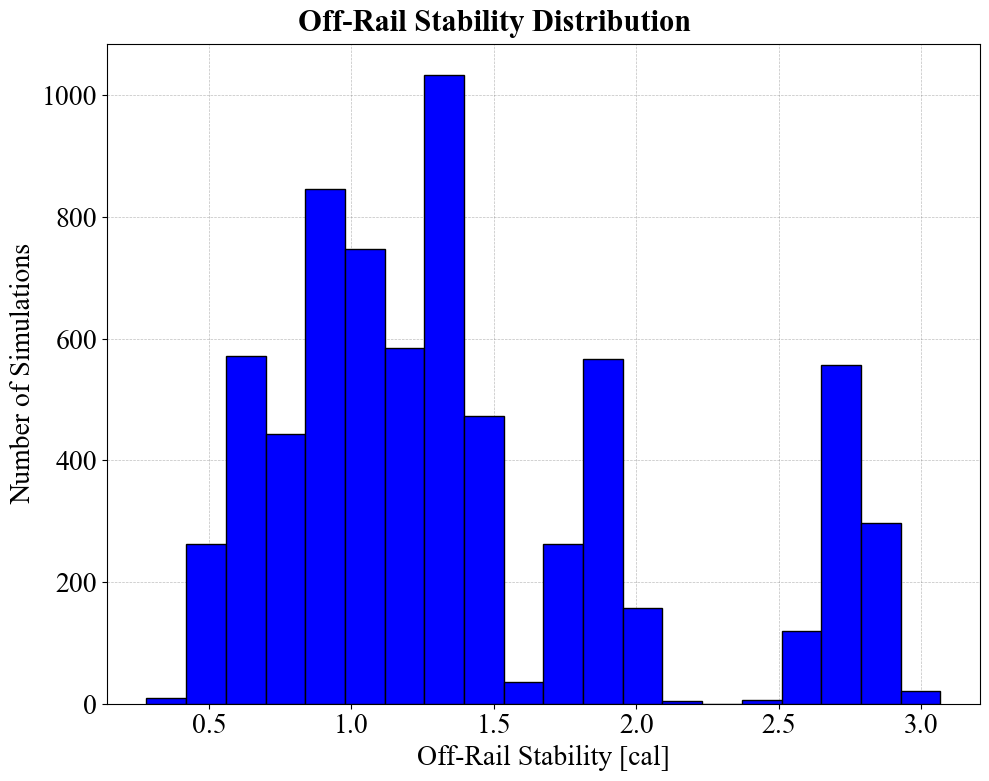

In [31]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Off-Rail Stability Distribution', y=0.97)

off_rail_stability_arr = np.array(all_off_rod_stability).reshape(-1)
    
ax.hist(off_rail_stability_arr, bins=20, edgecolor='black', facecolor='blue', zorder=10)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Off-Rail Stability [cal]')
ax.set_ylabel('Number of Simulations')

plt.show()

In [32]:
print(f'Mean Apogee Altitude = {np.mean(all_apogee_altitudes):.2f}, Std Dev = {np.std(all_apogee_altitudes):.3f}')
print(f'Mean Apogee Time = {np.mean(all_apogee_times):.2f}, Std Dev = {np.std(all_apogee_times):.3f}')
print(f'Mean Max Velocity = {np.mean(all_max_velocity):.2f}, Std Dev = {np.std(all_max_velocity):.3f}')
print(f'Mean Max Acceleration = {np.mean(all_max_acceleration):.2f}, Std Dev = {np.std(all_max_acceleration):.3f}')
print(f'Mean Off-Rod Velocity = {np.mean(all_off_rod_velocity):.2f}, Std Dev = {np.std(all_off_rod_velocity):.3f}')
print(f'Mean Full Flight Duration = {np.mean(all_full_flight_duration):.2f}, Std Dev = {np.std(all_full_flight_duration):.3f}')
print(f'Mean Ground Hit Velocity = {np.mean(all_ground_hit_velocity):.2f}, Std Dev = {np.std(all_ground_hit_velocity):.3f}')
print(f'Mean Off-Rod Stability = {np.mean(all_off_rod_stability):.2f}, Std Dev = {np.std(all_off_rod_stability):.3f}')
print(f'Mean Descent Time = {np.mean(np.array(all_full_flight_duration) - np.array(all_apogee_times)):.2f}, Std Dev = {np.std(np.array(all_full_flight_duration) - np.array(all_apogee_times)):.3f}')

Mean Apogee Altitude = 4686.64, Std Dev = 118.103
Mean Apogee Time = 17.09, Std Dev = 0.205
Mean Max Velocity = 619.40, Std Dev = 10.072
Mean Max Acceleration = 1249.44, Std Dev = 0.112
Mean Off-Rod Velocity = 87.37, Std Dev = 1.015
Mean Full Flight Duration = 100.88, Std Dev = 2.025
Mean Ground Hit Velocity = 15.68, Std Dev = 0.282
Mean Off-Rod Stability = 1.40, Std Dev = 0.668
Mean Descent Time = 83.79, Std Dev = 1.893
